In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [19]:
t = 1
mu = -1.6 * t
X, Y = 10, 50

lattice = Lattice(X, Y)

U0 = 2.0 * t * 0
U = U0 * np.ones(lattice.X)
V0 = 5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V * 0
H = Hamiltonian(t, mu, lattice, U=None, V_prime=None, V=V, F_init=[0.1, -0.1, 0.1j, -0.1j])

In [20]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
0j


In [21]:
bdg_self_consistency(H, maxiter=200, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 0.56375059612629
Relative error: 563750596126.2899
Average_old: 0j
Average_new: (0.17700919813790042+0j)
F_xplus:
Absolute error: 0.1946206607509206
Relative error: 1.9462066074897435
Average_old: (0.09999999999999999+0j)
Average_new: (0.16464684764946444+0j)
F_xmin:
Absolute error: 0.028168543839006167
Relative error: 0.2816854383928786
Average_old: (-0.09999999999999999+0j)
Average_new: (-0.09318586115113175+0j)
F_yplus:
Absolute error: 0.15938712493596555
Relative error: 1.5938712493596554
Average_old: 0.1j
Average_new: (0.027102327373032503+0.13676618586326153j)
F_ymin:
Absolute error: 0.15938712493596555
Relative error: 1.5938712493596554
Average_old: -0.1j
Average_new: (0.027102327373032503-0.13676618586326153j)
Fuu_xplus:
Absolute error: 5.582179903984224e-17
Relative error: 5.582179903984224e-05
Average_old: 0j
Average_new: (3.7862396270960235e-18+0j)
Fuu_xmin:
Absolute error: 4.651204605906075e-17
Relative error: 4.651204605906075e-05
Average_o

Iteration 2:
F0:
Absolute error: 0.09965810481597882
Relative error: 0.566021121298978
Average_old: (0.17700919813790042+0j)
Average_new: (0.2080788088978471+0j)
F_xplus:
Absolute error: 0.11059646950352534
Relative error: 0.6655635566746485
Average_old: (0.16464684764946444+0j)
Average_new: (0.20092363530319818+0j)
F_xmin:
Absolute error: 0.03316374859131004
Relative error: 0.3614885465521512
Average_old: (-0.09318586115113175+0j)
Average_new: (-0.0821520482876358+0j)
F_yplus:
Absolute error: 0.09212860725748
Relative error: 0.6291735806606404
Average_old: (0.027102327373032503+0.13676618586326153j)
Average_new: (0.04593642110000163+0.15662104961022277j)
F_ymin:
Absolute error: 0.09212860725748
Relative error: 0.6291735806606404
Average_old: (0.027102327373032503-0.13676618586326153j)
Average_new: (0.04593642110000163-0.15662104961022277j)
Fuu_xplus:
Absolute error: 5.772774484887595e-17
Relative error: 5.7726793390016095e-05
Average_old: (3.7862396270960235e-18+0j)
Average_new: (6.31

In [22]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 2.217144654119318e-05
Relative error: 8.767103888457488e-05
Average_old: (0.25498218734683736+0j)
Average_new: (0.25498822702496043+0j)
F_xplus:
Absolute error: 0.0001349499015076137
Relative error: 0.001353261473431204
Average_old: (0.09549497867249308+0j)
Average_new: (0.09545138293957803+0j)
F_xmin:
Absolute error: 0.00011330138272850087
Relative error: 0.019836698102074852
Average_old: (-0.00322687125588647+0j)
Average_new: (-0.0031899049984518476+0j)
F_yplus:
Absolute error: 3.2422528765276954e-05
Relative error: 0.00014736880235045367
Average_old: (0.12530975584479784+0.18757405418891704j)
Average_new: (0.1253175045885818+0.18757834243819452j)
F_ymin:
Absolute error: 3.2422528765276954e-05
Relative error: 0.00014736880235045367
Average_old: (0.12530975584479784-0.18757405418891704j)
Average_new: (0.1253175045885818-0.18757834243819452j)
Fuu_xplus:
Absolute error: 1.936710404270187e-17
Relative error: 1.936713464253265e-05
Average_old: (1.556802257

In [23]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
(0.25498822702496043+0j)


In [24]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [25]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = F_xmin       # site i gets bond (i,i-1).T

print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)

(0.044388579572113444+0j)
0.18757834243819452j
(-0.04189991975753751+0j)
(0.08341758483104429+0j)


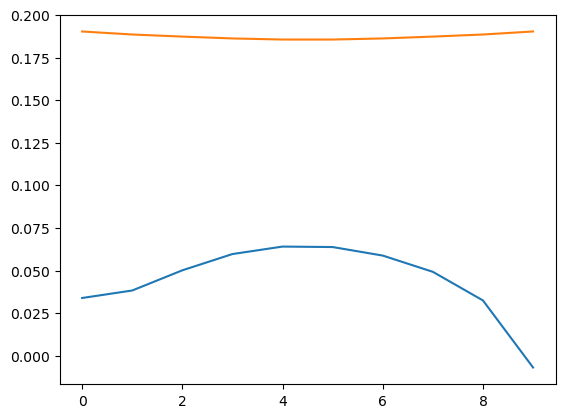

In [30]:
plt.plot(np.real(Fx_p- Fx_m)/2)
plt.plot(np.imag(F_yplus - F_ymin)/2)

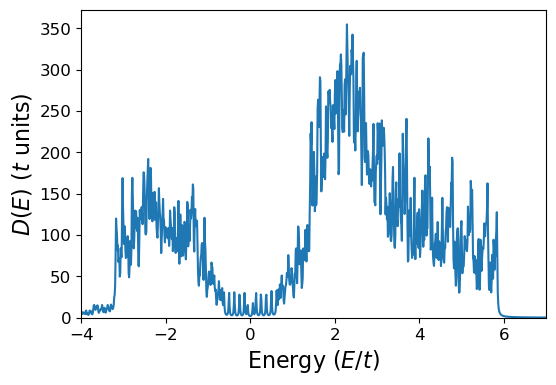

In [27]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.01)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [28]:
print(H.free_energy(0))

-1369.642645940055


In [12]:
# %prun H.dos(energies, eta=1e-3)